##QUESTIONS##
- what is the advantage... ? **Answer:** This removes the discontinuity at $\theta = \pm\pi$ and makes learning easier for the network.
- quelle architecture de NN ils ont utilisé ?
- quels resultats ils ont ? **Answer:** les memes

## Exercise 1: Neural network tracking

The basic center-of-mass tracking method that we used in the [vision tutorial](../week4/vision.ipynb) can fail when the target blends into the background. In this exercise, we will train a neural network to infer the target location directly from the fly's retinal images.

To train the network, we first need a dataset of images paired with the target's ground-truth location. This has already been implemented in [collect_data.py](collect_data.py). The script takes a few minutes to run, so a pre-generated dataset is provided in [assets/data.npz](assets/data.npz).

Let's start by loading the dataset:

images.shape = (10000, 2, 16, 31)
r_list.shape = (10000,)
theta_list.shape = (10000,)


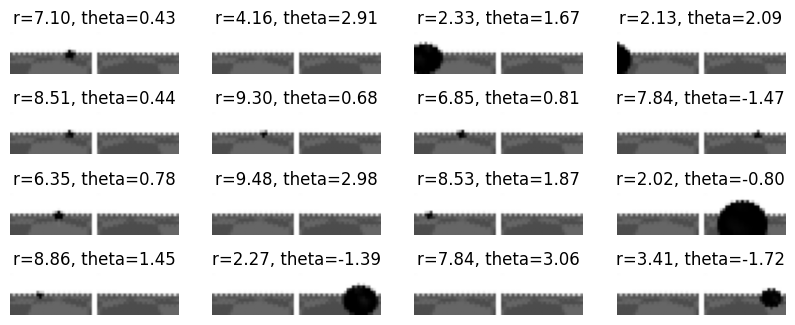

In [1]:
import matplotlib.pyplot as plt
import numpy as np

with np.load("assets/data.npz") as data:
    images = data["images"]
    r_list = data["r_list"]
    theta_list = data["theta_list"]

print(f"images.shape = {images.shape}")
print(f"r_list.shape = {r_list.shape}")
print(f"theta_list.shape = {theta_list.shape}")

# Display the first 16 paired eye images.
fig, axes = plt.subplots(4, 4, figsize=(10, 4))
separator_bar = np.ones((images.shape[-2], 2))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(
        np.concatenate([images[idx, 0], separator_bar, images[idx, 1]], axis=-1),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"r={r_list[idx]:.2f}, theta={theta_list[idx]:.2f}")
    ax.axis("off")

We will convert the target position from polar coordinates $(r, \theta)$ into a rotated Cartesian coordinate system. The two basis vectors point 45° to the left and right of the fly, respectively.

<img src="assets/coordinates.png" width="600">

Implement the conversion below.

**Question:** What is the advantage of this encoding compared with predicting $r$ and $\theta$ directly? 

**Answer:** To compare both side and know if the obstacle is closer to the right or the left.

In [17]:
################################################################
# TODO: Convert the polar coordinates to Cartesian coordinates.

coords_lr = np.array([r_list*np.cos(np.pi/4-theta_list),r_list*np.cos(np.pi/4+theta_list)]).T

################################################################

# The shape should be (n_samples, 2).
assert coords_lr.shape == (len(images), 2)
coords_lr = coords_lr.astype(np.float32)

Next, create the PyTorch dataset splits and data loaders:

In [18]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

dataset = TensorDataset(torch.from_numpy(images), torch.from_numpy(coords_lr))
split_names = ["train", "val", "test"]
split_generator = torch.Generator().manual_seed(0)
dataset_splits = dict(
    zip(split_names, random_split(dataset, [0.8, 0.1, 0.1], generator=split_generator))
)

batch_size = 32
loaders = {
    split_name: DataLoader(
        split_dataset,
        batch_size=batch_size,
        shuffle=split_name == "train",
    )
    for split_name, split_dataset in dataset_splits.items()
}

Construct your neural network model in the following cell. A small convolutional neural network should be sufficient for this dataset.

In [26]:
from torch import nn
import torch.nn.functional as F


class Model(nn.Module):
    """Convolutional regressor for target position prediction."""

    def __init__(self):
        super().__init__()
        #########################################
        # TODO: Define your layers here
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1) #padding to add a zero edge
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) 
        self.pool  = nn.MaxPool2d(2)                              
        
        
        self.fc1 = nn.Linear(32 * 8 * 15, 64)
        self.fc2 = nn.Linear(64, 2)  
        
        #########################################

    def forward(self, x):
        #########################################
        # TODO: Define the forward pass
        x = F.relu(self.conv1(x))   
        x = F.relu(self.conv2(x))   
        x = self.pool(x)            
        
        x = x.flatten(start_dim=1)  
        
        x = F.relu(self.fc1(x))     
        x = self.fc2(x)             
        return x
        #########################################

In [27]:
from copy import deepcopy
import torch.optim as optim


NUM_EPOCHS = 100
LEARNING_RATE = 1e-3


def evaluate_loss(model, data_loader, criterion):
    """Compute the mean loss over a data loader."""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in data_loader:
            predictions = model(inputs)
            total_loss += criterion(predictions, labels).item()
    return total_loss / len(data_loader)


model = Model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_model_state = deepcopy(model.state_dict())
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for inputs, labels in loaders["train"]:
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(loaders["train"])
    val_loss = evaluate_loss(model, loaders["val"], criterion)
    print(f"epoch={epoch:03d}, train_loss={train_loss:0.4f}, val_loss={val_loss:0.4f}")

    if val_loss < best_val_loss:
        best_model_state = deepcopy(model.state_dict())
        best_val_loss = val_loss

model.load_state_dict(best_model_state)

epoch=000, train_loss=15.1310, val_loss=9.2605
epoch=001, train_loss=6.3227, val_loss=4.7761
epoch=002, train_loss=3.8418, val_loss=3.6911
epoch=003, train_loss=2.8602, val_loss=2.6730
epoch=004, train_loss=2.4106, val_loss=2.4615
epoch=005, train_loss=2.2123, val_loss=2.2683
epoch=006, train_loss=2.0433, val_loss=2.0325
epoch=007, train_loss=1.9040, val_loss=2.0692
epoch=008, train_loss=1.8437, val_loss=2.0097
epoch=009, train_loss=1.8015, val_loss=1.8743
epoch=010, train_loss=1.7795, val_loss=1.9809
epoch=011, train_loss=1.7182, val_loss=1.8009
epoch=012, train_loss=1.6762, val_loss=1.7962
epoch=013, train_loss=1.6976, val_loss=2.2481
epoch=014, train_loss=1.6496, val_loss=1.7787
epoch=015, train_loss=1.6422, val_loss=1.7935
epoch=016, train_loss=1.6362, val_loss=1.8500
epoch=017, train_loss=1.6131, val_loss=1.8542
epoch=018, train_loss=1.6120, val_loss=1.8322
epoch=019, train_loss=1.5794, val_loss=1.7816
epoch=020, train_loss=1.5801, val_loss=1.9255
epoch=021, train_loss=1.5726, val

<All keys matched successfully>

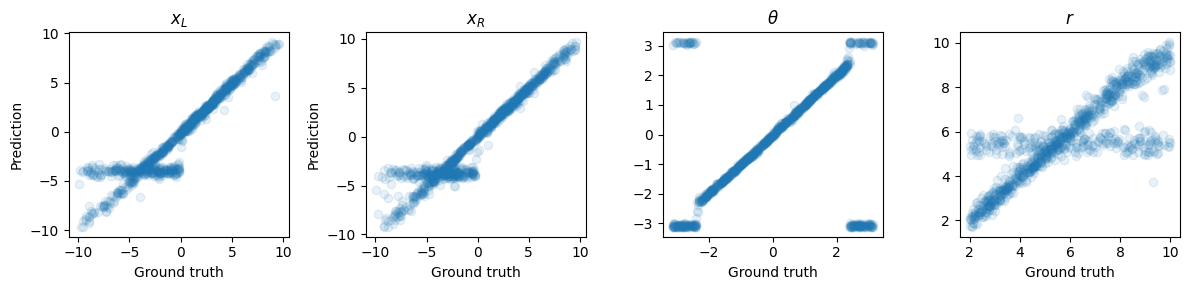

In [29]:
def decode_coords_lr(coords_lr):
    """Convert the rotated left-right encoding back to polar coordinates."""
    coords_complex = coords_lr @ np.array([1.0, -1.0j]) * np.exp(1.0j * np.pi / 4)
    theta = np.angle(coords_complex)
    radius = np.abs(coords_complex)
    return radius, theta


test_indices = dataset_splits["test"].indices
coords_lr_test = coords_lr[test_indices]
with torch.no_grad():
    coords_lr_pred = model(torch.from_numpy(images[test_indices])).numpy()

r_pred, theta_pred = decode_coords_lr(coords_lr_pred)

fig, axs = plt.subplots(1, 4, figsize=(12, 3), tight_layout=True)
for i in range(2):
    axs[i].scatter(coords_lr_test[:, i], coords_lr_pred[:, i], alpha=0.1)
    axs[i].set_xlabel("Ground truth")
    axs[i].set_ylabel("Prediction")

axs[2].scatter(theta_list[test_indices], theta_pred, alpha=0.1)
axs[2].set_xlabel("Ground truth")
axs[3].scatter(r_list[test_indices], r_pred, alpha=0.1)
axs[3].set_xlabel("Ground truth")

for ax, title in zip(axs, ["$x_L$", "$x_R$", "$\\theta$", "$r$"]):
    ax.set_title(title)

Do a scatter plot of the ground-truth target locations in the test set, colored by the prediction error. Based on the prediction error plot below, can you estimate the fly's visual field?

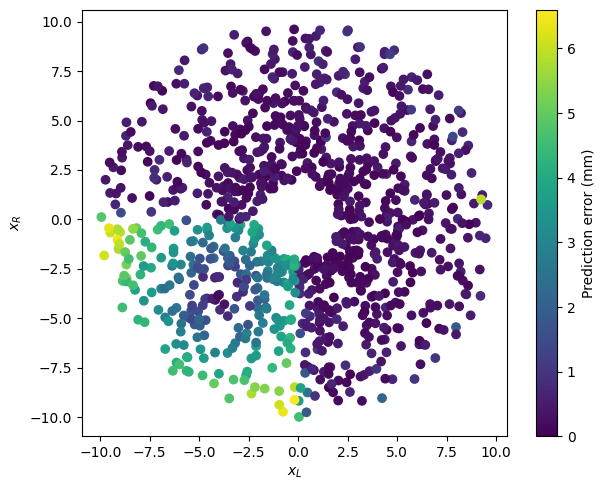

In [30]:
fig, ax = plt.subplots(figsize=(6.5, 5), tight_layout=True)
################################################################################
# TODO: compute the prediction error as the Euclidean distance between the
# predicted and ground-truth coordinates, and make a scatter plot of the
# ground-truth target locations in the test set, colored by the prediction
# error.
prediction_error = np.sqrt(((coords_lr_pred - coords_lr_test) ** 2).sum(axis=1))
scatter = ax.scatter(
    coords_lr_test[:, 0],
    coords_lr_test[:, 1],
    c=prediction_error,
    cmap="viridis",
    vmin=0,
)

################################################################################
ax.set_xlabel("$x_L$")
ax.set_ylabel("$x_R$")
ax.set_aspect("equal")
fig.colorbar(scatter, ax=ax, label="Prediction error (mm)")